# DSC630 Predictive Analytics - Term Project
## Can Personality Predict Drug Use? A Machine Learning Approach 
By Nana Noda-Morgan

In [5]:
#Import dataset from UCI ML Repo
from ucimlrepo import fetch_ucirepo

# Fetch dataset for ID = 373
drug_data = fetch_ucirepo(id=373)

# Get the main DataFrame
df = drug_data.data.original.copy()

print("Shape:", df.shape)
df.info()

Shape: (1885, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1885 entries, 0 to 1884
Data columns (total 32 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         1885 non-null   int64  
 1   age        1885 non-null   float64
 2   gender     1885 non-null   float64
 3   education  1885 non-null   float64
 4   country    1885 non-null   float64
 5   ethnicity  1885 non-null   float64
 6   nscore     1885 non-null   float64
 7   escore     1885 non-null   float64
 8   oscore     1885 non-null   float64
 9   ascore     1885 non-null   float64
 10  cscore     1885 non-null   float64
 11  impuslive  1885 non-null   float64
 12  ss         1885 non-null   float64
 13  alcohol    1885 non-null   object 
 14  amphet     1885 non-null   object 
 15  amyl       1885 non-null   object 
 16  benzos     1885 non-null   object 
 17  caff       1885 non-null   object 
 18  cannabis   1885 non-null   object 
 19  choc       1885 non-null   obj

In [7]:
# Import Libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

#from sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay)

# from imblearn
from imblearn.pipeline import Pipeline 
from imblearn.over_sampling import SMOTE

# make sure any future warnings are supressed in the output
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


pd.set_option("display.max_columns", 100)

SEED = 42
np.random.seed(SEED)

# Demographics & personality
demographic_cols = ["age", "gender", "education", "country", "ethnicity"]
personality_cols = ["nscore", "escore", "oscore", "ascore", "cscore", "impuslive", "ss"]

# All 18 drug names from UCI original
drug_cols = [
    "alcohol", "amphet", "amyl", "benzos", "cannabis", "choc",
    "coke", "caff", "crack", "ecstasy", "heroin", "ketamine", "legalh",
    "lsd", "meth", "mushrooms", "nicotine", "vsa", "semer"
]


In [9]:
#Create a function to convert the 7 class drug usage into binary (user vs non-user)

def binarize_drug(series):
    """
    Convert the 7 drug classes to binary:
    - 0: CL0 (never), CL1 (over a decade ago)
    - 1: CL2-CL6 (used within last decade/year/month/week/day)
    """
    def to_bin(v):
        s = str(v).strip().upper()
        if s in ("CL0", "CL1"):
            return 0
        # anything else (CL2-CL6) 
        return 1

    return series.map(to_bin).astype(int)

# Create *_bin columns for each drug
for d in drug_cols:
    bin_col = f"{d}_bin"
    df[bin_col] = binarize_drug(df[d])

# Quick check
df[[f"{d}_bin" for d in drug_cols]].head()

,alcohol_bin,amphet_bin,amyl_bin,benzos_bin,cannabis_bin,choc_bin,coke_bin,caff_bin,crack_bin,ecstasy_bin,heroin_bin,ketamine_bin,legalh_bin,lsd_bin,meth_bin,mushrooms_bin,nicotine_bin,vsa_bin,semer_bin
0,1,1,0,1,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0
1,1,1,1,0,1,1,1,1,0,1,0,1,0,1,1,0,1,0,0
2,1,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0
3,1,0,0,1,1,1,1,1,0,0,0,1,0,0,0,0,1,0,0
4,1,0,0,0,1,1,0,1,0,0,0,0,0,0,0,1,1,0,0


In [11]:
#Categorize drugs and create targets
stimulant_list   = ["amphet", "coke", "crack"]
depressant_list  = ["benzos", "heroin", "meth"]
hallucinogen_list= ["lsd", "mushrooms", "ketamine", "ecstasy"]

df["stimulant_user"]    = (df[[f"{d}_bin" for d in stimulant_list]].max(axis=1) >= 1).astype(int)
df["depressant_user"]   = (df[[f"{d}_bin" for d in depressant_list]].max(axis=1) >= 1).astype(int)
df["hallucinogen_user"] = (df[[f"{d}_bin" for d in hallucinogen_list]].max(axis=1) >= 1).astype(int)

df[["stimulant_user", "depressant_user", "hallucinogen_user"]].mean().rename("positive_rate")

stimulant_user       0.462069
depressant_user      0.447215
hallucinogen_user    0.493899
Name: positive_rate, dtype: float64

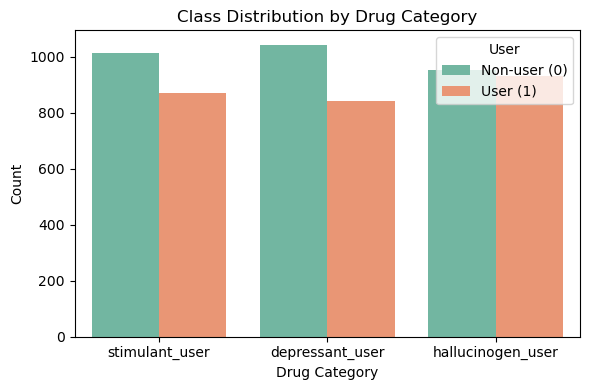

In [13]:
#Check class distribution
import seaborn as sns

#use melt() to turn into long format
class_dist_df = df.melt(
    value_vars=["stimulant_user", "depressant_user", "hallucinogen_user"],
    var_name="Drug Category",
    value_name="User"
)

#create a plot to show the class distribution by drug category
plt.figure(figsize=(6,4))
sns.countplot(
    data=class_dist_df,
    x="Drug Category",
    hue="User",
    palette="Set2"
)
plt.title("Class Distribution by Drug Category")
plt.ylabel("Count")
plt.xlabel("Drug Category")
plt.legend(title="User", labels=["Non-user (0)", "User (1)"])
plt.tight_layout()
plt.show()

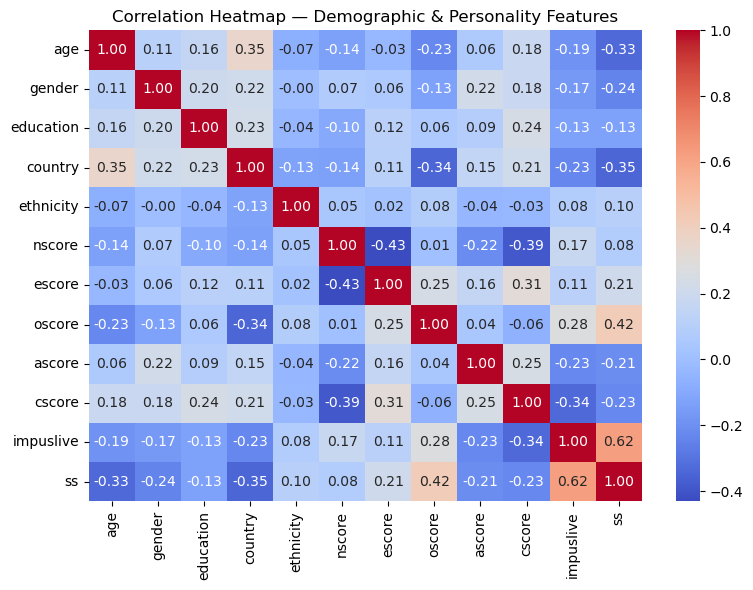

In [94]:
# Select numeric columns only and create correlation heatmap
num_cols = demographic_cols + personality_cols
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap — Demographic & Personality Features")
plt.tight_layout()
plt.show()

In [15]:
# All binary drug columns 
drug_bin_cols = [f"{d}_bin" for d in drug_cols]

# Targets (created above)
target_cols = ["stimulant_user", "depressant_user", "hallucinogen_user"]

# Feature set: demographics + personality
feature_cols = demographic_cols + personality_cols

# X = only features; y = pick one target at a time
X_all = df[feature_cols].copy()

print("X shape:", X_all.shape)
X_all.head()

X shape: (1885, 12)


,age,gender,education,country,ethnicity,nscore,escore,oscore,ascore,cscore,impuslive,ss
0,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,-0.21712,-1.18084
1,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,-0.14277,-0.71126,-0.21575
2,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,-1.37983,0.40148
3,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,0.58489,-1.37983,-1.18084
4,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,1.30612,-0.21712,-0.21575


In [17]:
#Train/Test split without scaling/SMOTE yet

from collections import OrderedDict

#Choose which target to run
targets_to_run = ["stimulant_user", "depressant_user", "hallucinogen_user"]

#Create a container to store test metrics
test_metrics = OrderedDict()

In [19]:
#Define pipelines for logistic regression (lr) and random forest (rf)
pipe_lr = Pipeline([
    ("scale", StandardScaler()),
    ("smote", SMOTE(random_state=SEED, n_jobs=-1)),
    ("clf", LogisticRegression(max_iter=1000, solver="liblinear"))
])

pipe_rf = Pipeline([
    ("scale", StandardScaler()),
    ("smote", SMOTE(random_state=SEED, n_jobs=-1)),
    ("clf", RandomForestClassifier(n_estimators=500, random_state=SEED, n_jobs=-1))
])

# Cross-validation settings
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {"roc_auc": "roc_auc", "pr_auc": "average_precision", "accuracy": "accuracy"}

In [21]:
#Create function for the modeling and displaying of results

def evaluate_for_target(
    target_col,
    X_all,
    df,
    feature_names, # demographic_cols + personality_cols
    show_curves=True,
    show_feature_plots=True,
    save_prefix=None 
):
    print("\n" + "==============================================================================")
    print(f"TARGET: {target_col}")
    print("===============================================================================")

    # Prepare y and split
    y = df[target_col].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y, test_size=0.20, stratify=y, random_state=SEED
    )

    results = {}

    for name, pipe in [("Logistic Regression", pipe_lr), ("Random Forest", pipe_rf)]:
        print(f"\n--- {name}: Cross-Validation (train only) ---")
        cv_res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
        for k in scoring:
            print(f"{k.upper():>8}: {cv_res[f'test_{k}'].mean():.3f} ± {cv_res[f'test_{k}'].std():.3f}")

        # Fit on TRAIN only
        pipe.fit(X_train, y_train)

        # --- Test metrics ---
        y_prob = pipe.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        test_roc = roc_auc_score(y_test, y_prob)
        test_pr  = average_precision_score(y_test, y_prob)
        test_acc = accuracy_score(y_test, y_pred)

        print(f"\n--- {name}: Test Set ---")
        print(f"ROC AUC : {test_roc:.3f}")
        print(f"PR  AUC : {test_pr:.3f}")
        print(f"Accuracy: {test_acc:.3f}")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, digits=3))
        print("Confusion Matrix [TN FP; FN TP]:")
        print(confusion_matrix(y_test, y_pred))

        if show_curves:
            RocCurveDisplay.from_predictions(y_test, y_prob)
            plt.title(f"{name} — ROC ({target_col})")
            plt.show()

            PrecisionRecallDisplay.from_predictions(y_test, y_prob)
            plt.title(f"{name} — PR ({target_col})")
            plt.show()

        # get top features per model
        if show_feature_plots:
            if name == "Logistic Regression":
                coefs = pipe.named_steps["clf"].coef_.ravel()
                lr_df = (pd.DataFrame({"feature": feature_names, "coef": coefs})
                           .assign(abs_coef=lambda d: d["coef"].abs())
                           .sort_values("abs_coef", ascending=False)
                           .head(10))
                plt.figure(figsize=(8,5))
                plt.barh(lr_df["feature"][::-1], lr_df["coef"][::-1])
                plt.title(f"Logistic Regression Coefficients — Top 10 ({target_col})")
                plt.xlabel("Coefficient of standardized features")
                plt.tight_layout()
                if save_prefix:
                    out = f"{save_prefix}_logreg_coeffs_{target_col}.png"
                    os.makedirs(os.path.dirname(out), exist_ok=True)
                    plt.savefig(out, dpi=200, bbox_inches="tight")
                    print(f"Saved: {os.path.abspath(out)}")
                plt.show()
                results.setdefault("top_features", {})["logistic_regression"] = lr_df

            if name == "Random Forest":
                imps = pipe.named_steps["clf"].feature_importances_
                rf_df = (pd.DataFrame({"feature": feature_names, "importance": imps})
                           .sort_values("importance", ascending=False)
                           .head(10))
                plt.figure(figsize=(8,5))
                plt.barh(rf_df["feature"][::-1], rf_df["importance"][::-1])
                plt.title(f"Random Forest Feature Importance — Top 10 ({target_col})")
                plt.xlabel("Importance")
                plt.tight_layout()
                if save_prefix:
                    out = f"{save_prefix}_rf_importance_{target_col}.png"
                    os.makedirs(os.path.dirname(out), exist_ok=True)
                    plt.savefig(out, dpi=200, bbox_inches="tight")
                    print(f"Saved: {os.path.abspath(out)}")
                plt.show()
                results.setdefault("top_features", {})["random_forest"] = rf_df

        results[name] = {"roc_auc": test_roc, "pr_auc": test_pr, "accuracy": test_acc}

    return results


TARGET: stimulant_user

--- Logistic Regression: Cross-Validation (train only) ---
 ROC_AUC: 0.802 ± 0.024
  PR_AUC: 0.740 ± 0.040
ACCURACY: 0.723 ± 0.015

--- Logistic Regression: Test Set ---
ROC AUC : 0.803
PR  AUC : 0.745
Accuracy: 0.729

Classification Report:
              precision    recall  f1-score   support

           0      0.739     0.768     0.754       203
           1      0.717     0.684     0.700       174

    accuracy                          0.729       377
   macro avg      0.728     0.726     0.727       377
weighted avg      0.729     0.729     0.729       377

Confusion Matrix [TN FP; FN TP]:
[[156  47]
 [ 55 119]]


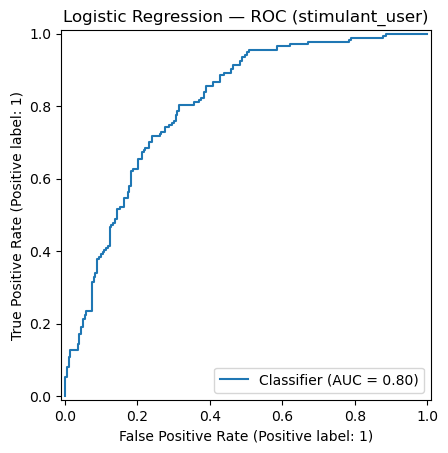

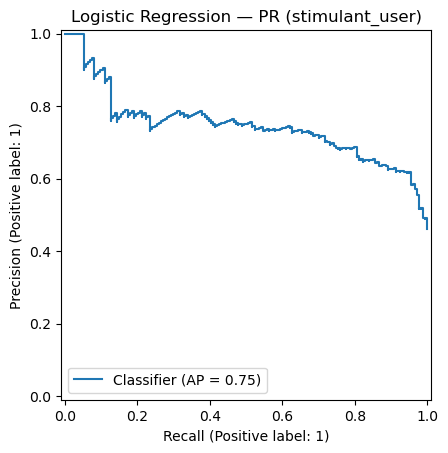

Saved: C:\Users\nanan\OneDrive\Documents\DSC630\figs\stims_logreg_coeffs_stimulant_user.png


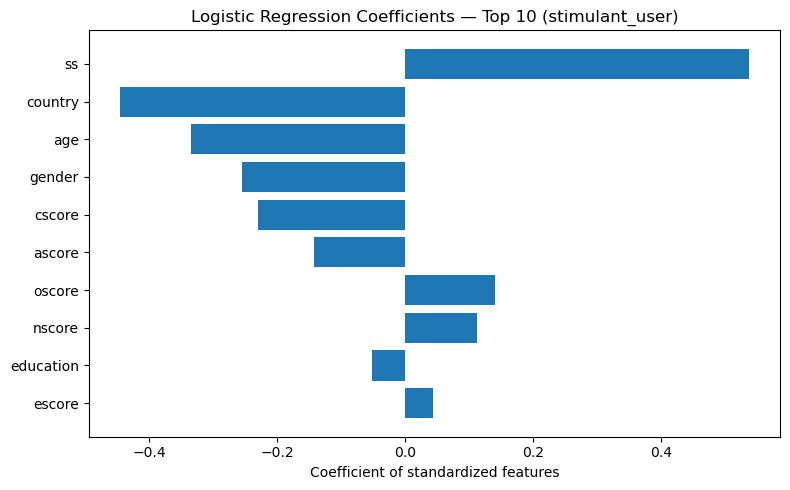


--- Random Forest: Cross-Validation (train only) ---
 ROC_AUC: 0.803 ± 0.019
  PR_AUC: 0.734 ± 0.030
ACCURACY: 0.734 ± 0.019

--- Random Forest: Test Set ---
ROC AUC : 0.787
PR  AUC : 0.703
Accuracy: 0.714

Classification Report:
              precision    recall  f1-score   support

           0      0.741     0.719     0.730       203
           1      0.683     0.707     0.695       174

    accuracy                          0.714       377
   macro avg      0.712     0.713     0.712       377
weighted avg      0.714     0.714     0.714       377

Confusion Matrix [TN FP; FN TP]:
[[146  57]
 [ 51 123]]


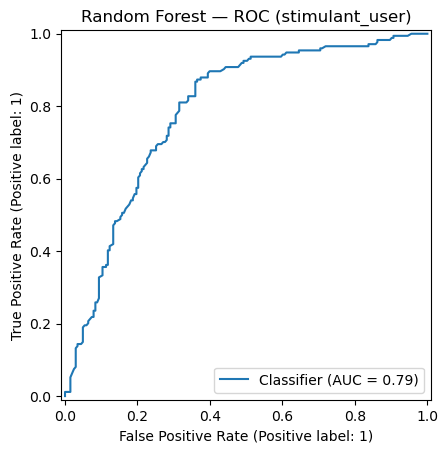

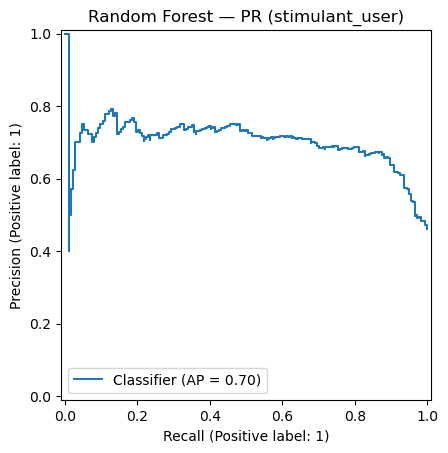

Saved: C:\Users\nanan\OneDrive\Documents\DSC630\figs\stims_rf_importance_stimulant_user.png


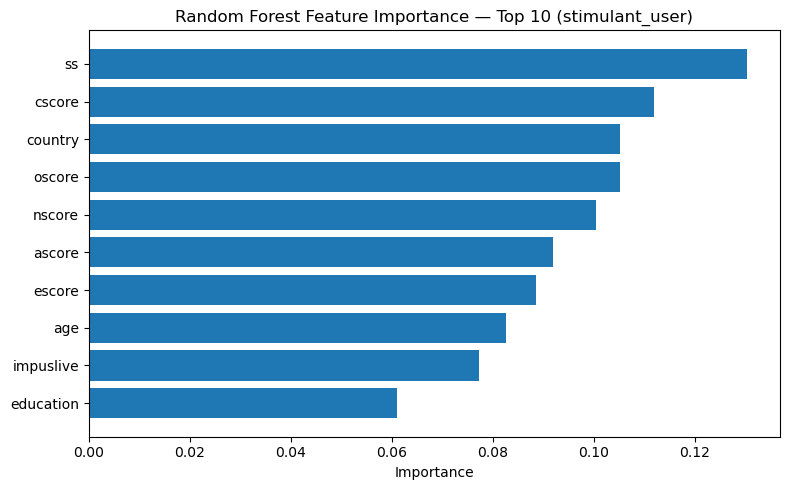


TARGET: depressant_user

--- Logistic Regression: Cross-Validation (train only) ---
 ROC_AUC: 0.770 ± 0.019
  PR_AUC: 0.729 ± 0.021
ACCURACY: 0.712 ± 0.018

--- Logistic Regression: Test Set ---
ROC AUC : 0.800
PR  AUC : 0.737
Accuracy: 0.724

Classification Report:
              precision    recall  f1-score   support

           0      0.757     0.736     0.746       208
           1      0.686     0.710     0.698       169

    accuracy                          0.724       377
   macro avg      0.722     0.723     0.722       377
weighted avg      0.725     0.724     0.725       377

Confusion Matrix [TN FP; FN TP]:
[[153  55]
 [ 49 120]]


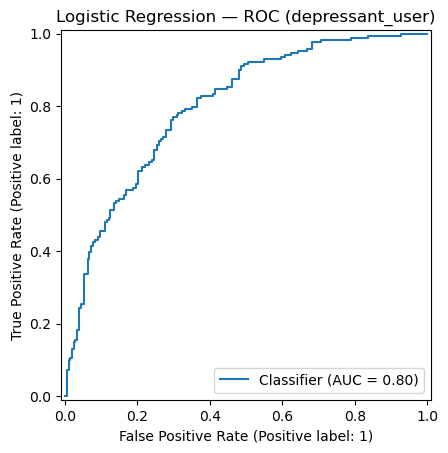

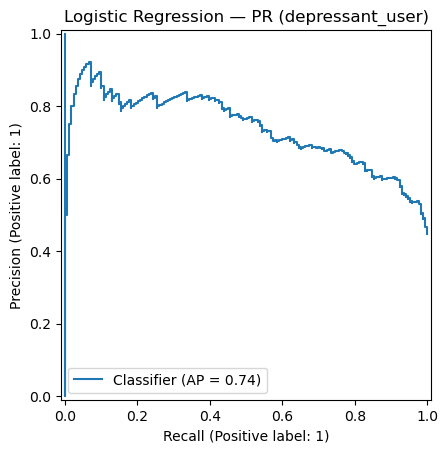

Saved: C:\Users\nanan\OneDrive\Documents\DSC630\figs\stims_logreg_coeffs_depressant_user.png


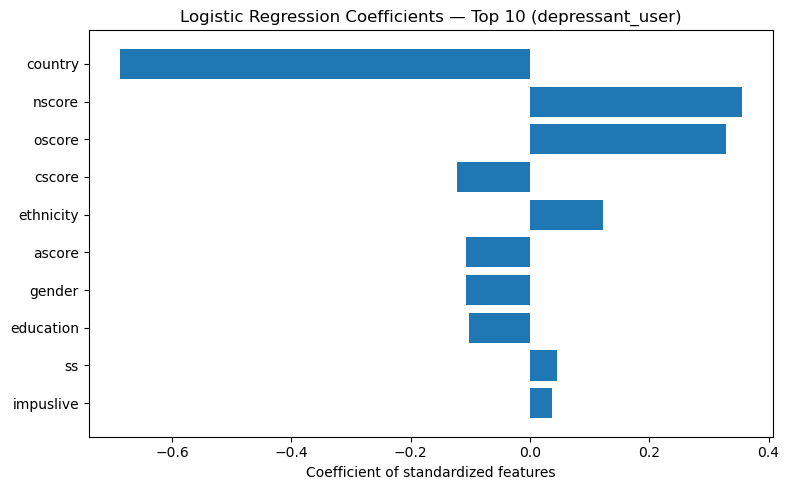


--- Random Forest: Cross-Validation (train only) ---
 ROC_AUC: 0.762 ± 0.019
  PR_AUC: 0.708 ± 0.021
ACCURACY: 0.715 ± 0.017

--- Random Forest: Test Set ---
ROC AUC : 0.781
PR  AUC : 0.708
Accuracy: 0.698

Classification Report:
              precision    recall  f1-score   support

           0      0.730     0.716     0.723       208
           1      0.659     0.675     0.667       169

    accuracy                          0.698       377
   macro avg      0.695     0.695     0.695       377
weighted avg      0.698     0.698     0.698       377

Confusion Matrix [TN FP; FN TP]:
[[149  59]
 [ 55 114]]


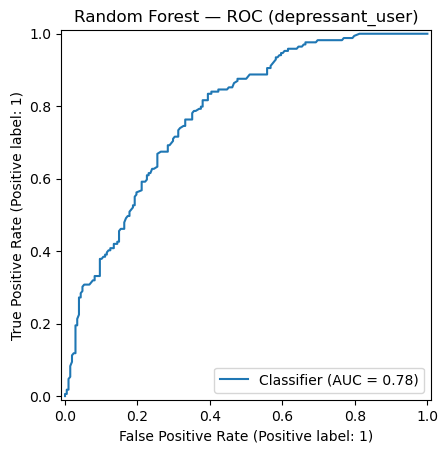

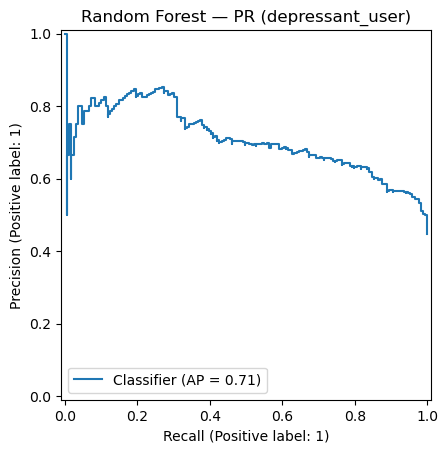

Saved: C:\Users\nanan\OneDrive\Documents\DSC630\figs\stims_rf_importance_depressant_user.png


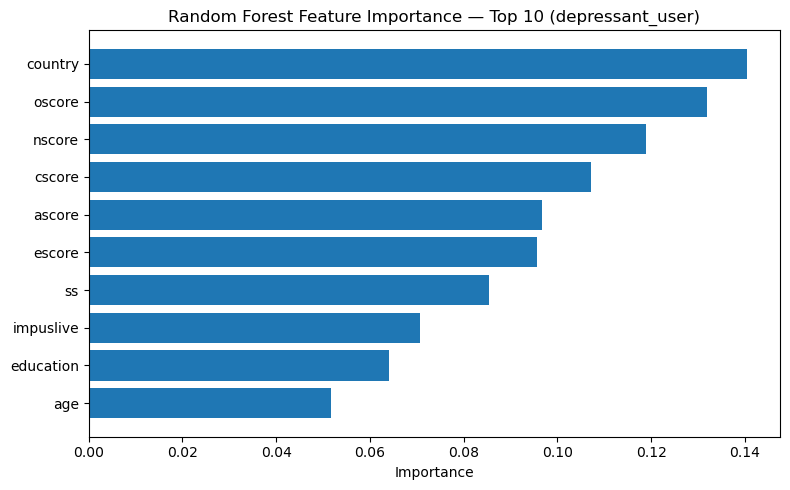


TARGET: hallucinogen_user

--- Logistic Regression: Cross-Validation (train only) ---
 ROC_AUC: 0.872 ± 0.011
  PR_AUC: 0.860 ± 0.011
ACCURACY: 0.793 ± 0.018

--- Logistic Regression: Test Set ---
ROC AUC : 0.861
PR  AUC : 0.842
Accuracy: 0.769

Classification Report:
              precision    recall  f1-score   support

           0      0.741     0.838     0.786       191
           1      0.807     0.699     0.749       186

    accuracy                          0.769       377
   macro avg      0.774     0.768     0.768       377
weighted avg      0.774     0.769     0.768       377

Confusion Matrix [TN FP; FN TP]:
[[160  31]
 [ 56 130]]


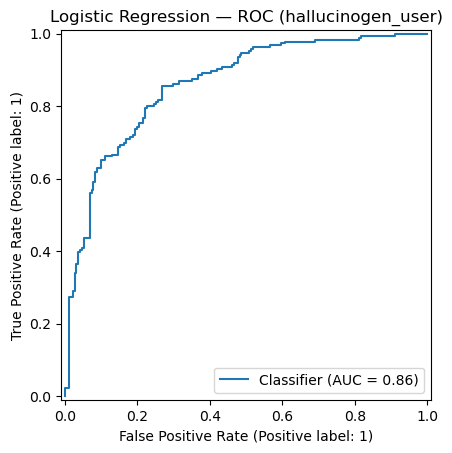

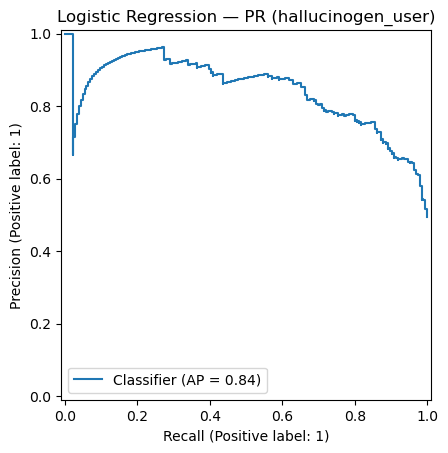

Saved: C:\Users\nanan\OneDrive\Documents\DSC630\figs\stims_logreg_coeffs_hallucinogen_user.png


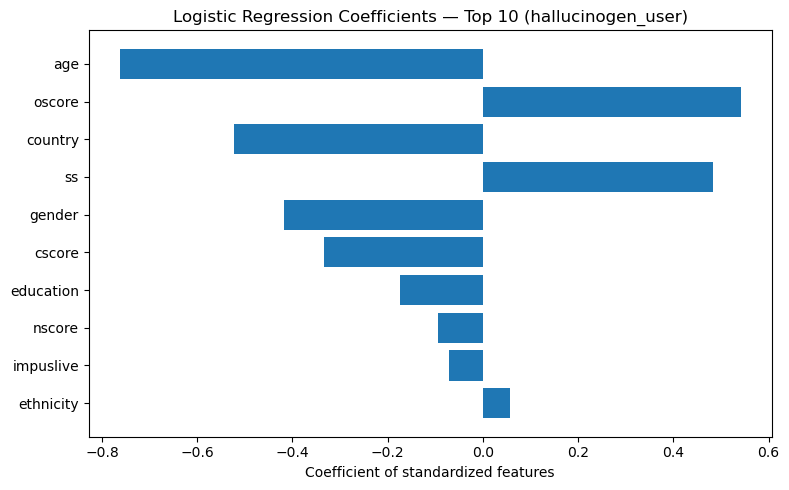


--- Random Forest: Cross-Validation (train only) ---
 ROC_AUC: 0.868 ± 0.017
  PR_AUC: 0.850 ± 0.019
ACCURACY: 0.788 ± 0.018

--- Random Forest: Test Set ---
ROC AUC : 0.867
PR  AUC : 0.851
Accuracy: 0.788

Classification Report:
              precision    recall  f1-score   support

           0      0.773     0.822     0.797       191
           1      0.805     0.753     0.778       186

    accuracy                          0.788       377
   macro avg      0.789     0.787     0.787       377
weighted avg      0.789     0.788     0.787       377

Confusion Matrix [TN FP; FN TP]:
[[157  34]
 [ 46 140]]


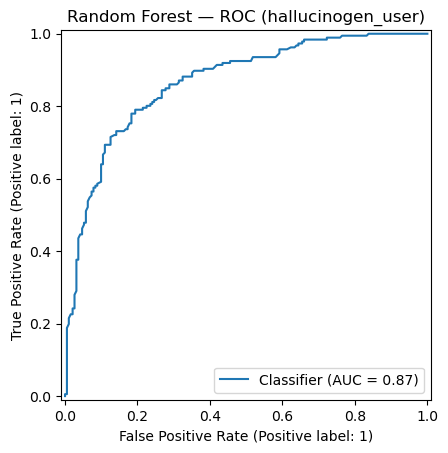

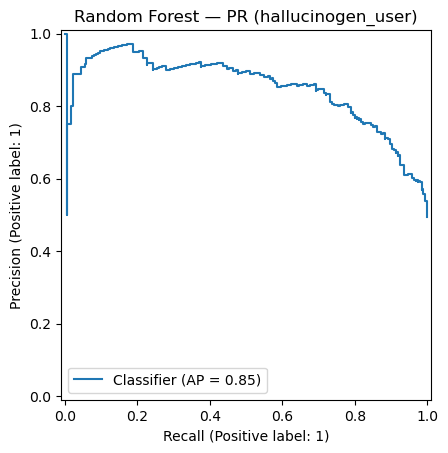

Saved: C:\Users\nanan\OneDrive\Documents\DSC630\figs\stims_rf_importance_hallucinogen_user.png


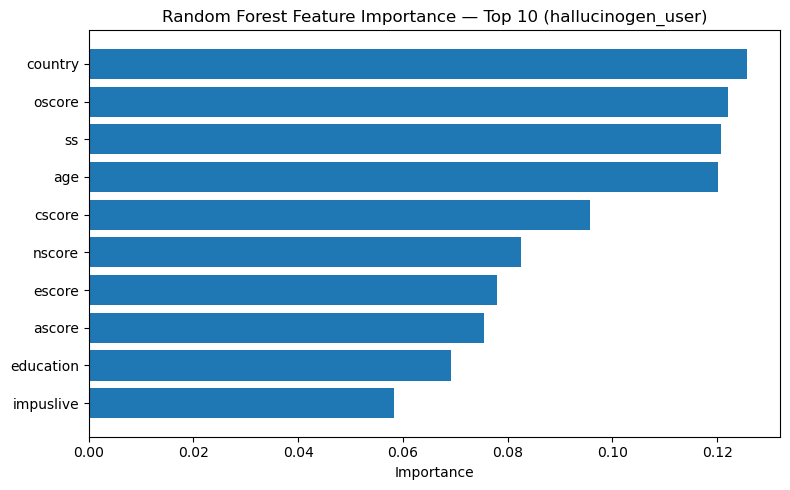

,target,model,logistic_regression,random_forest,roc_auc,pr_auc,accuracy
0,depressant_user,Logistic Regression,NaN,NaN,0.799642,0.736944,0.724138
1,depressant_user,Random Forest,NaN,NaN,0.780525,0.708024,0.697613
2,depressant_user,top_features,feature coef abs_coef 3 countr...,feature importance 3 country 0.1...,NaN,NaN,NaN
3,hallucinogen_user,Logistic Regression,NaN,NaN,0.861397,0.842211,0.769231
4,hallucinogen_user,Random Forest,NaN,NaN,0.866563,0.850870,0.787798
5,hallucinogen_user,top_features,feature coef abs_coef 0 ag...,feature importance 3 country 0.1...,NaN,NaN,NaN
6,stimulant_user,Logistic Regression,NaN,NaN,0.803097,0.745499,0.729443
7,stimulant_user,Random Forest,NaN,NaN,0.787257,0.702807,0.713528
8,stimulant_user,top_features,feature coef abs_coef 11 s...,feature importance 11 ss 0.1...,NaN,NaN,NaN


In [23]:
feature_names = demographic_cols + personality_cols

#Run the function for each target
for tgt in targets_to_run:
    test_metrics[tgt] = evaluate_for_target(
    tgt, X_all, df, feature_names,
    show_curves=True, show_feature_plots=True, save_prefix="figs/stims")

# Collect into one table
summary_rows = []
for tgt, res in test_metrics.items():
    for model_name, scores in res.items():
        row = {"target": tgt, "model": model_name}
        row.update(scores)
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values(["target", "model"]).reset_index(drop=True)
summary_df

## Interpretation of Results

Using this leakage-free pipeline with SMOTE applied only on the training data, both Logistic Regression and Random Forest models achieved solid predictive performance across the three drug use categories:

- **Stimulant Use (Amphetamines, Cocaine, Crack)**  
  - Logistic Regression: ROC AUC = 0.803, PR AUC = 0.745, Accuracy = 0.729  
  - Random Forest: ROC AUC = 0.787, PR AUC = 0.703, Accuracy = 0.714  
  - *Interpretation*: Personality and demographic variables provide moderate ability to distinguish stimulant users from non-users, with Logistic Regression slightly outperforming Random Forest.

- **Depressant Use (Benzodiazepines, Heroin, Methadone)**  
  - Logistic Regression: ROC AUC = 0.800, PR AUC = 0.737, Accuracy = 0.724  
  - Random Forest: ROC AUC = 0.781, PR AUC = 0.708, Accuracy = 0.698  
  - *Interpretation*: Depressant use prediction is somewhat less accurate than stimulants or hallucinogens, but Logistic Regression still shows a small advantage.

- **Hallucinogen Use (LSD, Mushrooms, Ketamine, Ecstasy)**  
  - Logistic Regression: ROC AUC = 0.861, PR AUC = 0.842, Accuracy = 0.769  
  - Random Forest: ROC AUC = 0.867, PR AUC = 0.851, Accuracy = 0.788  
  - *Interpretation*: Hallucinogen use is the most predictable category, with Random Forest slightly outperforming Logistic Regression.

**Overall Patterns**:
- Both models are viable, but performance differences are small.  
- Logistic Regression tends to perform slightly better for stimulant and depressant categories, Random Forest slightly better for hallucinogens.  
- PR AUC values being close to ROC AUC values means balanced performance even with imbalanced classes.  
- Results confirm that demographic and personality features are informative predictors of drug use patterns.

**Next Steps**:
- Consider incorporating more nuanced feature engineering or alternative models (e.g., gradient boosting).  
- Evaluate calibration of probability outputs if these models are to be used for decision-making.


## Conclusion  

The predictive analytics results show that personality traits and demographic characteristics hold meaningful predictive power for drug use, but performance varies by drug category and model. Logistic regression achieved the highest performance for predicting stimulant and depressant use, while random forest performed best for hallucinogen use. This suggests that different drug categories may have distinct patterns that are better captured by different types of models.

One model didn't emerge as the universal best across all drug categories, reinforcing the value of testing multiple algorithms. Across all models, openness to experience and sensation-seeking consistently ranked to be the most important predictors, along with certain demographic features like age and education level.

Overall, these findings support the hypothesis that personality profiles, combined with basic demographic data, can help identify individuals at higher risk of drug use. However, the predictive strength and key features vary by drug category, indicating the need for custom approaches when applying these models in prevention or intervention contexts.